In [32]:
#decision tree

#objective: predicting the political affiliation of US county (based on the 2020 election)
#we'll first try a simple tree with 2-3 branches

import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv("US_Election_dataset_v1.csv", sep = ",", header=0)

cols = ["county","state","Gini Index","Density per square km","2020 Democrat vote %"]
df_subset= df[cols]




In [33]:
#defining a binary outcome variable: republican or democrat leaning states. 
df_subset["democrat_outcome"] = (df["2020 Democrat vote %"] > df["2020 Republican vote %"]).astype(int)
df_subset["republican_outcome"] = (df["2020 Republican vote %"] > df["2020 Democrat vote %"]).astype(int)

#check that both outcomes are mutually exclusive
df_subset["total_outcome_check"] = df_subset["democrat_outcome"] + df_subset["republican_outcome"]
df_subset["total_outcome_check"].hist


<bound method hist_series of 0       1
1       1
2       1
3       1
4       1
       ..
3138    1
3139    1
3140    1
3141    1
3142    1
Name: total_outcome_check, Length: 3143, dtype: int64>

[Text(0.7863911502041853, 0.9814814814814815, 'Density per square km <= 211.65\ngini = 0.291\nsamples = 3143\nvalue = [2588, 555]'),
 Text(0.63373687200124, 0.9444444444444444, 'Gini Index <= 0.477\ngini = 0.219\nsamples = 2891\nvalue = [2529, 362]'),
 Text(0.7100640111027126, 0.962962962962963, 'True  '),
 Text(0.45094844210483753, 0.9074074074074074, 'Density per square km <= 110.76\ngini = 0.174\nsamples = 2373\nvalue = [2144, 229]'),
 Text(0.27409354895953136, 0.8703703703703703, 'Gini Index <= 0.453\ngini = 0.152\nsamples = 2219\nvalue = [2035, 184]'),
 Text(0.06506298519263945, 0.8333333333333334, 'Gini Index <= 0.328\ngini = 0.119\nsamples = 1617\nvalue = [1514, 103]'),
 Text(0.013944795859689477, 0.7962962962962963, 'Gini Index <= 0.299\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.011644623346751006, 0.7592592592592593, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.016244968372627948, 0.7592592592592593, 'Density per square km <= 0.245\ngini = 0.5\nsamples = 2\nv

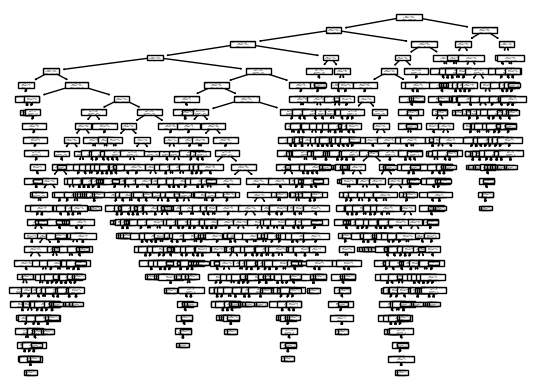

In [35]:
features = ["Gini Index", "Density per square km"]
			
x = df_subset[features]
y = df_subset["democrat_outcome"]

dtree = DecisionTreeClassifier()
dtree = dtree.fit(x, y)

tree.plot_tree(dtree, feature_names=features)